In [1]:
import os
import json
import numpy as np
import sympy as sp
from scipy.integrate import solve_ivp
from datetime import datetime 

from matplotlib.animation import FFMpegWriter
from matplotlib import rc
rc('animation', html='html5')

from IPython.display import HTML
from mpl_toolkits.mplot3d.proj3d import proj_transform

from geometry_param import get_params

In [2]:
VISUALIZE_ANIM_FLAG     = True
VISUALIZE_ANIM_FLAG_4   = False

SAVE_ANIM_FLAG          = False
SAVE_ANIM_FLAG_4        = False
SAVE_TRAJ_FLAG          = False

In [3]:
# =========================
# 1. DESERIALIZATION (reuse your exact logic)
# =========================
SYMPY_LOCALS = {name: getattr(sp, name) for name in dir(sp)}
SYMPY_LOCALS.update({
    "Derivative": sp.Derivative   # safety fallback
})

def deserialize_fast(obj):
    if isinstance(obj, dict) and "__sympy__" in obj:
        return eval(obj["expr"], SYMPY_LOCALS) #{"Symbol": sp.Symbol, "Matrix": sp.Matrix, **sp.__dict__})
    
    if isinstance(obj, dict):
        return {k: deserialize_fast(v) for k, v in obj.items()}
    
    if isinstance(obj, list):
        return [deserialize_fast(v) for v in obj]

In [4]:
# =========================
# 2. LOAD SYMBOLIC MODEL
# =========================
filename = "cache/3DOF_symbolic_data_04052026_0057.json"  # <-- update

with open(filename, "r") as f:
    raw = json.load(f)

data = deserialize_fast(raw)

M_sym = data['M']
h_sym = data['h']
Q_sym = data['Q']

# Extract symbols
n   = data['n']
nd  = data['nd']
ndd = data['ndd']

params_sym = data['params']

# Flatten arguments
state_syms = list(n) + list(nd)

param_syms = list(params_sym.values())

# External inputs (must match your symbolic definition!)
tau_syms = sp.symbols('tau1 tau2 tau3')
F_syms   = sp.symbols('Fx Fy Fz')

dyn_args = (
    *state_syms,
    *param_syms,
    *tau_syms,
    *F_syms
)

In [5]:
print("In M:", M_sym.free_symbols)
print("In h:", h_sym.free_symbols)
print("In Q:", Q_sym.free_symbols)

In M: {yO_A, xO_A, Iazz, ma, Iayy, xC_A, yB_A, Iby, zB_A, Icz, Iayz, n2, mb, zO_A, Iaxx, Iaxy, Ibz, Ibx, Iaxz, n3, Icx, Icy, xB_A, yC_A, zC_A, mc}
In h: {yO_A, xO_A, Iazz, ma, Iayy, xC_A, yB_A, Iby, zB_A, Iayz, Icz, n3d, n2, mb, zO_A, Iaxx, Iaxy, Ibz, Ibx, Iaxz, g, n3, Icx, Icy, xB_A, n2d, n1d, yC_A, zC_A, n1, mc}
In Q: {Fy, tau2, n3, tau1, Fz, yB_A, xB_A, Fx, zB_A, tau3, n2}


In [6]:
free_syms = (
    M_sym.free_symbols
    | h_sym.free_symbols
    | Q_sym.free_symbols
)

In [7]:
missing = free_syms - set(dyn_args)
print("Missing symbols:", missing)

Missing symbols: set()


In [8]:
# =========================
# 3. LAMBDIFY
# =========================
print("Lambdifying...")

M_func = sp.lambdify(dyn_args, M_sym, 'numpy')
h_func = sp.lambdify(dyn_args, h_sym, 'numpy')
Q_func = sp.lambdify(dyn_args, Q_sym, 'numpy')

print("Done.\n")

Lambdifying...
Done.



In [9]:
# =========================
# 4. NUMERIC PARAMETERS
# =========================

params_num = get_params()
param_vals = list(params_num.values())

In [10]:
# =========================
# 5. INPUTS (TEST)
# =========================
def tau_A(t):
    u = np.array([0.0, 0.0, 0.0])
    u[2] = 2.0*np.exp(-2*t)
    return u

def F_A(t):
    u = np.array([0.0, 0.0, 0.0])
    u[2] = np.sin(t)
    return u


# =========================
# 6. DYNAMICS FUNCTION
# =========================
def dynamics(t, x):
    n_val  = x[:3]
    nd_val = x[3:]

    tau = tau_A(t)
    F   = F_A(t)

    args = (
        *n_val,
        *nd_val,
        *param_vals,
        *tau,
        *F
    )

    M = np.array(M_func(*args), dtype=float)
    h = np.array(h_func(*args), dtype=float).reshape(3)
    Q = np.array(Q_func(*args), dtype=float).reshape(3)

    # Solve M * ndd = Q - h
    try:
        ndd_val = np.linalg.solve(M, Q - h)
    except np.linalg.LinAlgError:
        # fallback
        ndd_val = np.linalg.lstsq(M, Q - h, rcond=None)[0]

    return np.hstack([nd_val, ndd_val])

In [ ]:
# =========================
# 7. SIMULATION (solve_ivp)
# =========================
t_span      = (0.0, 10.0)
N_frames    = int(t_span[1]*50)
t_eval      = np.linspace(*t_span, N_frames)
dt          = t_eval[1] - t_eval[0]

# Small perturbation IC
x0 = np.array([
    0.0,  0.0,  0.0,    # angles in 3-2-1 convention: [yaw, pitch, roll] in degrees
    0.0,  0.0,  0.0      # angular rates in 3-2-1 convention: [yaw-rate, pitch-rate, roll-rate] in degrees
])

print("Running simulation...")

sol = solve_ivp(
    dynamics,
    t_span,
    x0*(np.pi/180),
    t_eval=t_eval,
    method='RK45',
    rtol=1e-6,
    atol=1e-8
)

print("Done.\n")

Running simulation...
Done.



In [12]:
# =========================
# 8. BASIC CHECK
# =========================
if not sol.success:
    print("Solver failed:", sol.message)
else:
    print("Solver success\n", sol.message,"\n")

print("Final state:\n", sol.y[:, -1])

Solver success
 The solver successfully reached the end of the integration interval. 

Final state:
 [44.48106091  0.05115025  0.4217175   4.72371624 -0.65574879 -1.12872982]


In [13]:
# =========================
# RESULTS DIRECTORY SETUP
# =========================
results_dir = "results"
os.makedirs(results_dir, exist_ok=True)

timestamp = datetime.now().strftime("%d%m%Y_%H%M")
# base_name = f"sim_{timestamp}"

# npz_path = os.path.join(results_dir, base_name + ".npz")
# video_path = os.path.join(results_dir, base_name + ".mp4")

EL residual check: M(n) @ ndd + h(n, nd) - Q
Max |residual| per equation: [2.22044605e-16 3.60822483e-16 2.22044605e-16]
RMS residual per equation  : [2.53776367e-17 1.12230077e-16 4.57843170e-17]
Max |residual| overall     : 3.608224830031759e-16
PASS: residuals are below tolerance (1e-08).


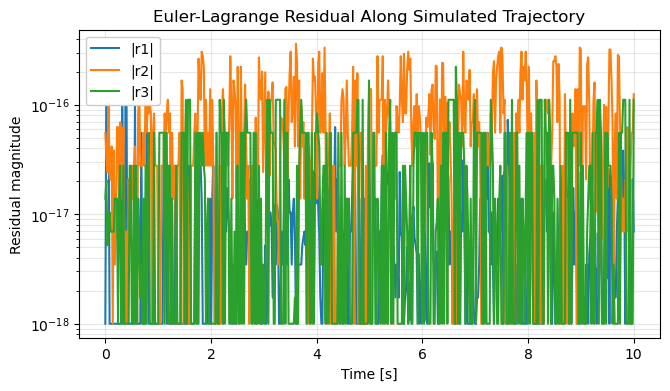

In [14]:
# =========================
# 9. EULER-LAGRANGE RESIDUAL CHECK ON SIMULATED TRAJECTORY
# =========================
# The saved model is in standard form:
#     M(n) * ndd + h(n, nd) = Q(n, inputs)
# Therefore the EL residual along the simulated trajectory is:
#     r = M(n) * ndd + h(n, nd) - Q(n, inputs)
# We recompute ndd from the same dynamics solve used by solve_ivp at each saved state.
import matplotlib.pyplot as plt

def evaluate_model_terms(t_current, state):
    n_val = state[:3]
    nd_val = state[3:]
    tau = tau_A(t_current)
    F = F_A(t_current)

    args = (
        *n_val,
        *nd_val,
        *param_vals,
        *tau,
        *F,
    )

    M = np.array(M_func(*args), dtype=float)
    h = np.array(h_func(*args), dtype=float).reshape(3)
    Q = np.array(Q_func(*args), dtype=float).reshape(3)
    return M, h, Q

def acceleration_from_model(t_current, state):
    M, h, Q = evaluate_model_terms(t_current, state)
    try:
        return np.linalg.solve(M, Q - h)
    except np.linalg.LinAlgError:
        return np.linalg.lstsq(M, Q - h, rcond=None)[0]

if not sol.success:
    raise RuntimeError(f"Simulation failed, so residuals are not meaningful: {sol.message}")

states = sol.y.T
residuals = np.zeros((states.shape[0], 3), dtype=float)
accelerations = np.zeros_like(residuals)

for k, (t_current, state) in enumerate(zip(sol.t, states)):
    M, h, Q = evaluate_model_terms(t_current, state)
    ndd_val = acceleration_from_model(t_current, state)

    accelerations[k] = ndd_val
    residuals[k] = M @ ndd_val + h - Q

max_abs_each = np.max(np.abs(residuals), axis=0)
max_abs_all = float(np.max(np.abs(residuals)))
rms_each = np.sqrt(np.mean(residuals**2, axis=0))

print("EL residual check: M(n) @ ndd + h(n, nd) - Q")
print("Max |residual| per equation:", max_abs_each)
print("RMS residual per equation  :", rms_each)
print("Max |residual| overall     :", max_abs_all)

tol = 1e-8
if max_abs_all < tol:
    print(f"PASS: residuals are below tolerance ({tol}).")
else:
    print(f"WARN: residuals exceed tolerance ({tol}). Check conditioning, inputs, or symbolic export.")

fig, ax = plt.subplots(figsize=(7.5, 4.0))
plot_floor = 1e-18
for i in range(3):
    ax.semilogy(sol.t, np.maximum(np.abs(residuals[:, i]), plot_floor), label=f"|r{i + 1}|")

ax.set_xlabel("Time [s]")
ax.set_ylabel("Residual magnitude")
ax.set_title("Euler-Lagrange Residual Along Simulated Trajectory")
ax.grid(True, which="both", alpha=0.3)
ax.legend(framealpha=1.0)
plt.show()


In [15]:
# =========================
# 3D ARM ANIMATION
# =========================
# This cell uses the same DCM convention as 3dof_sympy_4.ipynb:
#     C_AN = R_x(n3) @ R_y(n2) @ R_z(n1)
#     v_N  = C_AN.T @ v_A
# Here n1, n2, n3 are the trajectory coordinates loaded in sol.y.

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# -------------------------
# Arm geometry for visualization
# -------------------------
# geometry_param.py contains COM locations and inertial parameters, but not the
# intermediate bent-arm nodes. Keep these segment lengths synchronized with
# arm_geometry_parameters.ipynb when you change the physical rig geometry.
mm = 1e-3
L_C_to_bend = 300.0 * mm
L_diagonal = 172.75416 * mm
L_bottom = 60.0 * mm
L_upright = 162.0 * mm

# Infer measured C -> O_A distance from the exported compensator COM location.
rC_A = np.array([params_num['xC_A'], params_num['yC_A'], params_num['zC_A']], dtype=float)
rB_A = np.array([params_num['xB_A'], params_num['yB_A'], params_num['zB_A']], dtype=float)
rO_A = np.array([params_num['xO_A'], params_num['yO_A'], params_num['zO_A']], dtype=float)

# In the geometry notebook convention, C lies on the no-bend side along -X_A.
C_to_OA = -rC_A[0]
if not np.allclose(rC_A[1:], [0.0, 0.0], atol=1e-10):
    print('WARN: rC_A is not on the -X_A no-bend axis. Update the visualization reconstruction if needed.')
if C_to_OA < 0.0 or C_to_OA > L_C_to_bend:
    print('WARN: inferred C_to_OA is outside the no-bend segment:', C_to_OA)

if L_diagonal < L_upright:
    raise ValueError('L_diagonal must be at least L_upright for this bent-arm reconstruction.')

diagonal_x_run = float(np.sqrt(max(L_diagonal**2 - L_upright**2, 0.0)))

# Build physical arm nodes in a C-tip reference frame, then shift to A-frame.
pC_ref = np.array([0.0, 0.0, 0.0])
p_bend_ref = np.array([L_C_to_bend, 0.0, 0.0])
p_lower_ref = p_bend_ref + np.array([diagonal_x_run, 0.0, -L_upright])
p_bottom_ref = p_lower_ref + np.array([L_bottom, 0.0, 0.0])
pB_ref = p_bottom_ref + np.array([0.0, 0.0, L_upright])
pOA_ref = np.array([C_to_OA, 0.0, 0.0])

arm_nodes_A = np.vstack([pC_ref, p_bend_ref, p_lower_ref, p_bottom_ref, pB_ref]) - pOA_ref

# Check that reconstructed endpoints agree with geometry_param.py.
print('Endpoint check |C node - rC_A|:', np.linalg.norm(arm_nodes_A[0] - rC_A))
print('Endpoint check |B node - rB_A|:', np.linalg.norm(arm_nodes_A[-1] - rB_A))
if not np.allclose(arm_nodes_A[0], rC_A, atol=1e-8):
    print('WARN: reconstructed compensator endpoint does not match geometry_param.py.')
if not np.allclose(arm_nodes_A[-1], rB_A, atol=1e-8):
    print('WARN: reconstructed body endpoint does not match geometry_param.py. Check segment lengths.')

m_total = params_num['ma'] + params_num['mb'] + params_num['mc']
rG_A = (
    params_num['ma'] * rO_A
    + params_num['mb'] * rB_A
    + params_num['mc'] * rC_A
) / m_total

# -------------------------
# DCM: same convention as derivation notebook
# -------------------------
def C_AN_numeric(n1, n2, n3):
    """Direction cosine matrix from N components to A components."""
    c1, s1 = np.cos(n1), np.sin(n1)
    c2, s2 = np.cos(n2), np.sin(n2)
    c3, s3 = np.cos(n3), np.sin(n3)

    R1_n3 = np.array([
        [1.0, 0.0, 0.0],
        [0.0, c3,  s3],
        [0.0, -s3, c3],
    ])

    R2_n2 = np.array([
        [c2, 0.0, -s2],
        [0.0, 1.0, 0.0],
        [s2, 0.0, c2],
    ])

    R3_n1 = np.array([
        [c1,  s1, 0.0],
        [-s1, c1, 0.0],
        [0.0, 0.0, 1.0],
    ])

    return R1_n3 @ R2_n2 @ R3_n1


def points_A_to_N(points_A, state):
    C_AN = C_AN_numeric(state[0], state[1], state[2])
    return (C_AN.T @ np.asarray(points_A, dtype=float).T).T

if not sol.success:
    raise RuntimeError(f'Simulation failed, so animation is not meaningful: {sol.message}')

states = sol.y.T

# Precompute all animated points for stable true-scale axes.
all_points_N = []
for state in states:
    points_A = np.vstack([arm_nodes_A, rB_A, rC_A, rO_A, rG_A, np.zeros(3)])
    all_points_N.append(points_A_to_N(points_A, state))
all_points_N = np.vstack(all_points_N)

mins = all_points_N.min(axis=0)
maxs = all_points_N.max(axis=0)
center = 0.5 * (mins + maxs)
span = float(np.max(maxs - mins))
padding = max(0.08 * span, 0.05)
half_range = 0.5 * span + padding

fig = plt.figure(figsize=(7.5, 6.5))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlim(center[0] - half_range, center[0] + half_range)
ax.set_ylim(center[1] - half_range, center[1] + half_range)
ax.set_zlim(center[2] - half_range, center[2] + half_range)
ax.set_box_aspect((1, 1, 1))
ax.set_xlabel('X_N [m]')
ax.set_ylabel('Y_N [m]')
ax.set_zlabel('Z_N [m]')
ax.view_init(elev=22, azim=-45)
# ax.set_title('3DOF Training Rig Animation')
# ax.set_title(f't={0.00:.2f}s')

# Inertial reference axes and gravity direction.
axis_len = 0.18 * max(1.0, half_range / 0.2)
ax.quiver(0, 0, 0, axis_len, 0, 0, color='tab:red', linewidth=1.8, arrow_length_ratio=0.12, alpha=0.3)
ax.quiver(0, 0, 0, 0, axis_len, 0, color='tab:green', linewidth=1.8, arrow_length_ratio=0.12, alpha=0.3)
ax.quiver(0, 0, 0, 0, 0, axis_len, color='tab:blue', linewidth=1.8, arrow_length_ratio=0.12, alpha=0.3)
ax.quiver(0, 0, 0, 0, 0, -axis_len, color='0.35', linewidth=1.8, arrow_length_ratio=0.12)
ax.text(axis_len, 0, 0, 'X_N', color='tab:red')
ax.text(0, axis_len, 0, 'Y_N', color='tab:green')
ax.text(0, 0, axis_len, 'Z_N', color='tab:blue')
ax.text(0, 0, -axis_len, 'g', color='0.25')

arm_line, = ax.plot([], [], [], color='black', linewidth=3.0, marker='o', markersize=3.5)#, label='arm')
pivot_point, = ax.plot([], [], [], marker='x', color='crimson', markersize=9, linestyle='None', label='O_A pivot')
body_point, = ax.plot([], [], [], marker='o', color='darkorange', markeredgecolor='black', markersize=8, linestyle='None', label='body COM B')
comp_point, = ax.plot([], [], [], marker='o', color='darkblue', markeredgecolor='black', markersize=8, linestyle='None', label='compensator COM C')
arm_com_point, = ax.plot([], [], [], marker='o', color='purple', markeredgecolor='black', markersize=7, linestyle='None', label='arm COM')
total_com_point, = ax.plot([], [], [], marker='o', color='limegreen', markeredgecolor='black', markersize=7, linestyle='None', label='total COM')
ax.legend(loc='upper left', framealpha=1.0)

# =========================
# BODY-FRAME (B-frame at COM B)
# =========================

axis_len_B = 0.6 * axis_len  # smaller than inertial frame

# initial placeholders
B_x = ax.quiver(0,0,0,0,0,0,color='tab:red',linewidth=1.2,alpha=0.5)
B_y = ax.quiver(0,0,0,0,0,0,color='tab:green',linewidth=1.2,alpha=0.5)
B_z = ax.quiver(0,0,0,0,0,0,color='tab:blue',linewidth=1.2,alpha=0.5)

B_txt_x = ax.text(0, 0, 0, 'X_B', color='tab:red', fontsize=9)
B_txt_y = ax.text(0, 0, 0, 'Y_B', color='tab:green', fontsize=9)
B_txt_z = ax.text(0, 0, 0, 'Z_B', color='tab:blue', fontsize=9)

def update_text(txt, xyz):
    x2, y2, _ = proj_transform(xyz[0], xyz[1], xyz[2], ax.get_proj())
    txt.set_position((x2, y2))


frame_step = max(1, len(sol.t) // 180)
frame_indices = np.arange(0, len(sol.t), frame_step)



def set_point(plot_obj, point):
    plot_obj.set_data([point[0]], [point[1]])
    plot_obj.set_3d_properties([point[2]])


def init_anim():
    arm_line.set_data([], [])
    arm_line.set_3d_properties([])
    for obj in [pivot_point, body_point, comp_point, arm_com_point, total_com_point]:
        set_point(obj, np.array([np.nan, np.nan, np.nan]))
    return arm_line, pivot_point, body_point, comp_point, arm_com_point, total_com_point


def update_anim(k):
    state = states[k]
    nodes_N = points_A_to_N(arm_nodes_A, state)
    rB_N, rC_N, rO_N, rG_N, OA_N = points_A_to_N(
        np.vstack([rB_A, rC_A, rO_A, rG_A, np.zeros(3)]),
        state,
    )

    arm_line.set_data(nodes_N[:, 0], nodes_N[:, 1])
    arm_line.set_3d_properties(nodes_N[:, 2])

    set_point(pivot_point, OA_N)
    set_point(body_point, rB_N)
    set_point(comp_point, rC_N)
    set_point(arm_com_point, rO_N)
    set_point(total_com_point, rG_N)

    ax.set_title(
        f't={sol.t[k]:.2f}s\n'
        f'n1 (yaw) ={np.degrees(state[0]):+.1f} deg, '
        f'n2 (pitch) ={np.degrees(state[1]):+.1f} deg, '
        f'n3 (roll) ={np.degrees(state[2]):+.1f} deg'
    )

    #-----------------------------------------------------------------------------
    # =========================
    # UPDATE BODY FRAME AXES
    # =========================

    global B_x, B_y, B_z, B_txt_x, B_txt_y, B_txt_z

    origin_B = rB_N

    C_AN = C_AN_numeric(state[0], state[1], state[2])

    # correct transformation: body axes expressed in N
    xB = axis_len_B * (C_AN.T @ np.array([1.0, 0.0, 0.0]))
    yB = axis_len_B * (C_AN.T @ np.array([0.0, 1.0, 0.0]))
    zB = axis_len_B * (C_AN.T @ np.array([0.0, 0.0, 1.0]))

    # update quivers in-place (NO remove)
    B_x.remove()
    B_y.remove()
    B_z.remove()

    B_x = ax.quiver(*origin_B, *xB, color='tab:red', alpha=0.8)
    B_y = ax.quiver(*origin_B, *yB, color='tab:green', alpha=0.8)
    B_z = ax.quiver(*origin_B, *zB, color='tab:blue', alpha=0.8)

    # labels
    B_txt_x.remove()
    B_txt_y.remove()
    B_txt_z.remove()

    B_txt_x = ax.text(*(origin_B + xB), 'X_B', color='tab:red', fontsize=9)
    B_txt_y = ax.text(*(origin_B + yB), 'Y_B', color='tab:green', fontsize=9)
    B_txt_z = ax.text(*(origin_B + zB), 'Z_B', color='tab:blue', fontsize=9)
    #-----------------------------------------------------------------------------

    return arm_line, pivot_point, body_point, comp_point, arm_com_point, total_com_point



if VISUALIZE_ANIM_FLAG:

    ani = FuncAnimation(
        fig,
        update_anim,
        frames=len(states),
        init_func=init_anim,
        interval=1000/(len(states) / (sol.t[-1] - sol.t[0])),
        blit=False,
        repeat=False
    )

    plt.close(fig)
    display(HTML(ani.to_html5_video()))


Endpoint check |C node - rC_A|: 0.0
Endpoint check |B node - rB_A|: 1.199873533863638e-13


In [16]:
# =========================
# RESULTS DIRECTORY SETUP
# =========================
video_filename = os.path.join(
    results_dir,
    f"animation_{timestamp}.mp4"
)

# =========================
# EXPORT SETTINGS
# =========================
# T = t_span[1] - t_span[0]

# fps = len(t_eval) / T   # Matching the actual simulation time
T = t_span[1] - t_span[0]

frame_indices = np.arange(len(t_eval))  # IMPORTANT: no downsampling

fps = len(frame_indices) / T
dpi = 300               # increase for higher clarity (e.g., 150, 300, 600)


# =========================
# SAVE ANIMATION
# =========================
if SAVE_ANIM_FLAG:
    print("[SAVE] Writing animation...")

    writer = FFMpegWriter(
        fps=int(len(t_eval) / (t_eval[-1] - t_eval[0])),
        bitrate=5000
    )
    with writer.saving(fig, video_filename, dpi=300):
        for k in range(len(t_eval)):
            update_anim(k)   # IMPORTANT: use direct index, not frame_indices
            writer.grab_frame()

    print(f"[SAVE] Animation saved to: {video_filename}")

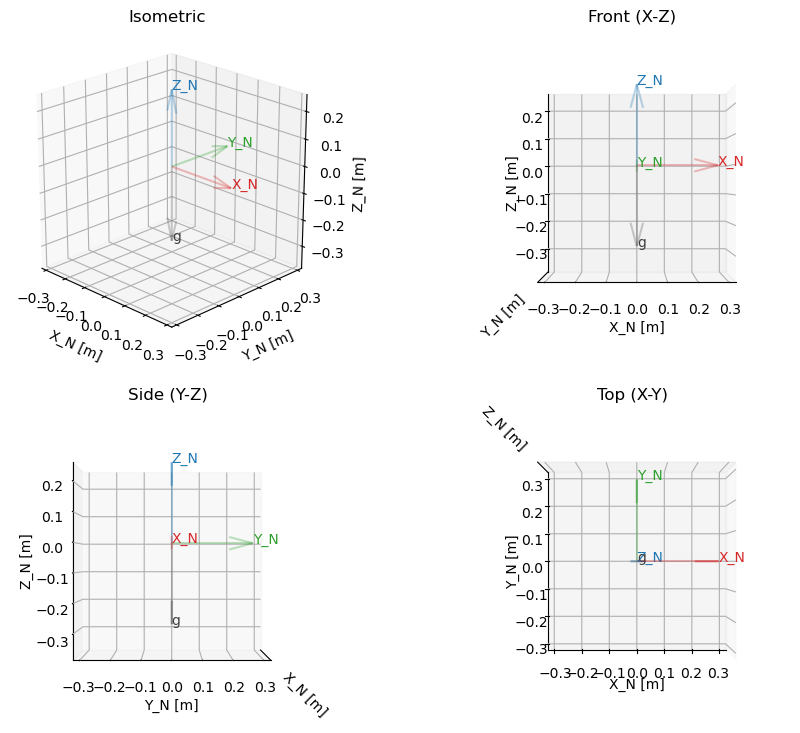

In [17]:
# =========================
# 3D ARM ANIMATION (4 synchronized views, cleaned)
# =========================

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import numpy as np

# =========================
# STATE
# =========================
states = sol.y.T
t = sol.t

# =========================
# FIGURE (4 VIEWS)
# =========================
fig = plt.figure(figsize=(11, 9))

ax_iso   = fig.add_subplot(221, projection='3d')
ax_front = fig.add_subplot(222, projection='3d')
ax_side  = fig.add_subplot(223, projection='3d')
ax_top   = fig.add_subplot(224, projection='3d')

axes = [ax_iso, ax_front, ax_side, ax_top]

# =========================
# COMMON AXES SETTINGS
# =========================
for ax in axes:
    ax.set_box_aspect((1, 1, 1))

    ax.set_xlim(center[0] - half_range, center[0] + half_range)
    ax.set_ylim(center[1] - half_range, center[1] + half_range)
    ax.set_zlim(center[2] - half_range, center[2] + half_range)

    ax.set_xlabel("X_N [m]")
    ax.set_ylabel("Y_N [m]")
    ax.set_zlabel("Z_N [m]")
    ax.grid(False, alpha=0.1)

# =========================
# VIEWS
# =========================
ax_iso.view_init(elev=22, azim=-45)
ax_front.view_init(elev=0, azim=-90)
ax_side.view_init(elev=0, azim=0)
ax_top.view_init(elev=90, azim=-90)

ax_iso.set_title("Isometric")
ax_front.set_title("Front (X-Z)")
ax_side.set_title("Side (Y-Z)")
ax_top.set_title("Top (X-Y)")

# =========================
# REMOVE TICKS (clean orthographic views)
# =========================
for ax in [ax_front, ax_side, ax_top]:
    if ax == ax_front:
        ax.set_yticks([])
    elif ax == ax_side:
        ax.set_xticks([])
    elif ax == ax_top:
        ax.set_zticks([])
        
# =========================
# AXES TRIADS
# =========================
axis_len = 0.18 * max(1.0, half_range / 0.2)

def add_axes(ax):
    ax.quiver(0, 0, 0, axis_len, 0, 0, color='tab:red', alpha=0.3)
    ax.quiver(0, 0, 0, 0, axis_len, 0, color='tab:green', alpha=0.3)
    ax.quiver(0, 0, 0, 0, 0, axis_len, color='tab:blue', alpha=0.3)
    ax.quiver(0, 0, 0, 0, 0, -axis_len, color='0.35', alpha=0.3)

    ax.text(axis_len, 0, 0, "X_N", color='tab:red')
    ax.text(0, axis_len, 0, "Y_N", color='tab:green')
    ax.text(0, 0, axis_len, "Z_N", color='tab:blue')
    ax.text(0, 0, -axis_len, "g", color='0.25')

for ax in axes:
    add_axes(ax)

# =========================
# ARTISTS
# =========================
def make_artists(ax):
    arm, = ax.plot([], [], [], 'k-', lw=3)

    pivot, = ax.plot([], [], [], 'x', color='crimson', ms=9)
    body,  = ax.plot([], [], [], 'o', color='darkorange', ms=7)
    comp,  = ax.plot([], [], [], 'o', color='darkblue', ms=7)
    armc,  = ax.plot([], [], [], 'o', color='purple', ms=6)
    total, = ax.plot([], [], [], 'o', color='limegreen', ms=6)

    B = {
        "x": None, "y": None, "z": None,
        "tx": None, "ty": None, "tz": None
    }

    return arm, pivot, body, comp, armc, total, B

artists = [make_artists(ax) for ax in axes]

# =========================
# HELPERS
# =========================
def set_point(obj, p):
    obj.set_data([p[0]], [p[1]])
    obj.set_3d_properties([p[2]])

def compute(state):
    nodes_N = points_A_to_N(arm_nodes_A, state)
    rB_N, rC_N, rO_N, rG_N, OA_N = points_A_to_N(
        np.vstack([rB_A, rC_A, rO_A, rG_A, np.zeros(3)]),
        state,
    )
    return nodes_N, rB_N, rC_N, rO_N, rG_N, OA_N

# =========================
# INIT
# =========================
def init():
    out = []
    for art in artists:
        arm, pivot, body, comp, armc, total, B = art

        arm.set_data([], [])
        arm.set_3d_properties([])

        for obj in [pivot, body, comp, armc, total]:
            set_point(obj, np.array([np.nan, np.nan, np.nan]))

        out += [arm, pivot, body, comp, armc, total]

    return out

# =========================
# UPDATE
# =========================
def update(k):
    state = states[k]
    nodes_N, rB_N, rC_N, rO_N, rG_N, OA_N = compute(state)

    for ax, art in zip(axes, artists):
        arm, pivot, body, comp, armc, total, B = art

        # arm
        arm.set_data(nodes_N[:, 0], nodes_N[:, 1])
        arm.set_3d_properties(nodes_N[:, 2])

        set_point(pivot, OA_N)
        set_point(body, rB_N)
        set_point(comp, rC_N)
        set_point(armc, rO_N)
        set_point(total, rG_N)

        # =========================
        # BODY FRAME
        # =========================
        origin_B = rB_N
        C_AN = C_AN_numeric(state[0], state[1], state[2])

        xB = axis_len_B * (C_AN.T @ np.array([1., 0., 0.]))
        yB = axis_len_B * (C_AN.T @ np.array([0., 1., 0.]))
        zB = axis_len_B * (C_AN.T @ np.array([0., 0., 1.]))

        for kq in ["x", "y", "z"]:
            if B[kq] is not None:
                B[kq].remove()

        B["x"] = ax.quiver(*origin_B, *xB, color='tab:red', alpha=0.8)
        B["y"] = ax.quiver(*origin_B, *yB, color='tab:green', alpha=0.8)
        B["z"] = ax.quiver(*origin_B, *zB, color='tab:blue', alpha=0.8)

        # =========================
        # FIXED TEXT (NO ROTATION)
        # =========================
        proj = ax.get_proj()

        def update_text(key, vec, label, color):
            pos = origin_B + vec

            x2, y2, _ = proj_transform(pos[0], pos[1], pos[2], proj)

            if B[key] is None:
                B[key] = ax.text2D(x2, y2, label, transform=ax.transData, color=color)
            else:
                B[key].set_position((x2, y2))
                B[key].set_color(color)

        update_text("tx", xB, "X_B", 'tab:red')
        update_text("ty", yB, "Y_B", 'tab:green')
        update_text("tz", zB, "Z_B", 'tab:blue')


    # SINGLE GLOBAL TITLE
    fig.suptitle(
        f"t={t[k]:.2f}s | "
        f"n1 (yaw)={np.degrees(state[0]):+.1f}°, "
        f"n2 (pitch)={np.degrees(state[1]):+.1f}°, "
        f"n3 (roll)={np.degrees(state[2]):+.1f}°",
        fontsize=12)

    return []

# =========================
# ANIMATION
# =========================
def render_frame(k):
    update(k)
    fig.canvas.draw_idle()
    fig.canvas.flush_events()

# =========================
# VISUALIZATION (INDEPENDENT)
# =========================

if VISUALIZE_ANIM_FLAG_4:

    ani = FuncAnimation(
        fig,
        update,
        frames=len(states),
        init_func=init,
        interval=1000 * (t[-1] - t[0]) / len(states),
        blit=False,
        repeat=False
    )

    plt.close(fig)
    display(HTML(ani.to_html5_video()))

# =========================
# SAVE MULTI-VIEW ANIMATION (INDEPENDENT)
# =========================
if SAVE_ANIM_FLAG_4:

    import os
    from matplotlib.animation import FFMpegWriter

    video_filename = os.path.join(
        results_dir,
        f"animation_multiview_{timestamp}.mp4"
    )


    writer = FFMpegWriter(
        fps=int(len(t_eval) / (t_eval[-1] - t_eval[0])),
        bitrate=5000
    )

    print("[SAVE] Writing animation (independent mode)...")

    # CRITICAL FIX: ensure initial frame is rendered
    init()
    fig.canvas.draw()

    with writer.saving(fig, video_filename, dpi=300):

        for k in range(len(states)):
            render_frame(k)     # NOT update() alone
            writer.grab_frame()

    print(f"[SAVE] Saved to: {video_filename}")




In [18]:
# =========================
# RESULTS DIRECTORY SETUP
# =========================
results_dir = "results"
os.makedirs(results_dir, exist_ok=True)

npz_filename = os.path.join(
    results_dir,
    f"sim_data_{timestamp}.npz"
)

# =========================
# EXTRACT DATA
# =========================
n = sol.y[:3, :].T
nd = sol.y[3:, :].T
t = sol.t

# Evaluate forces/torques along trajectory
tau_hist = []
F_hist = []

for k, tk in enumerate(t):
    tau_hist.append(tau_A(tk))
    F_hist.append(F_A(tk))

tau_hist = np.array(tau_hist)
F_hist = np.array(F_hist)

# =========================
# GEOMETRY + PARAMETERS
# =========================
geometry_data = {
    "L_C_to_bend": L_C_to_bend,
    "L_diagonal": L_diagonal,
    "L_bottom": L_bottom,
    "L_upright": L_upright,
    "C_to_OA": C_to_OA,
}

param_data = params_num  # already numeric dict

# =========================
# SAVE NPZ
# =========================

if SAVE_TRAJ_FLAG:
    np.savez_compressed(
        npz_filename,
        t=t,
        n=n,
        nd=nd,
        tau=tau_hist,
        F=F_hist,
        geometry=geometry_data,
        params=param_data
    )

    print(f"[SAVE] Simulation data saved to: {npz_filename}")